In [16]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

from utils.bivaraite_boxplot import plot_segmented_boxplot
from utils.cat_num_dep import hub_pruebas_num_cat
from utils.plotting import EDAPlotter
from utils.triple_plot import normality_report

In [2]:
df = pd.read_csv("../data/datos_inmobiliarios_clean.csv")

In [17]:
plotter = EDAPlotter(df)

In [3]:
df.head()

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,pub_month,mod_month,log_price_amount
0,casa,8.800000e+08,736000.00,5.500000e+06,160.0000,151.0,3.0,3.0,2,4.0,...,Suba,UB. Hacienda Cordoba Niza,4.711642,-74.062946,Alarma|Baño Auxiliar|Calentador|Canchas Deport...,Particular / Venta Directa,Particular,2023-01,2026-06,20.595432
1,casa,6.500000e+08,196727.91,4.237288e+06,153.4000,153.4,4.0,2.0,1,3.0,...,Barrios Unidos,Benjamin Herrera,4.655459,-74.073723,Baño Auxiliar|Colegios / Universidades|Estudio...,Particular / Venta Directa,Particular,2023-01,2026-07,20.292483
2,casa,6.250000e+08,643500.00,5.208333e+06,120.0000,120.0,4.0,3.0,2,5.0,...,Usaquen,Lagos DE Torca,4.764007,-74.042742,Baño Auxiliar|Calentador|Cancha de Tennis|Canc...,Particular / Venta Directa,Particular,2023-02,2026-06,20.253262
3,apartamento,4.700000e+08,560000.00,8.392857e+06,56.0000,58.0,1.0,2.0,1,4.0,...,Usaquen,Cedritos,4.721554,-74.036146,Ascensor|Barra estilo americano|Baño Auxiliar|...,Particular / Venta Directa,Particular,2023-03,2026-07,19.968243
4,casa,3.300000e+09,1317625.80,8.230622e+06,369.7528,350.0,4.0,3.0,2,6.0,...,Suba,San Jose DE Bavaria,4.769128,-74.061616,Balcón|Barra estilo americano|Baño Auxiliar|Ch...,Dávila Peña y CIA SAS,inmobiliaria,2023-03,2026-06,21.917188


In [4]:
df.columns

Index(['property_type', 'price_amount', 'admin_fee', 'price_per_m2',
       'area_built_m2', 'area_private_m2', 'bedrooms', 'bathrooms',
       'parking_spaces', 'stratum', 'floor', 'age_bracket_code',
       'age_bracket_label', 'construction_state', 'city', 'locality',
       'neighborhood', 'latitude', 'longitude', 'amenities', 'agency_name',
       'publisher_type', 'pub_month', 'mod_month', 'log_price_amount'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20253 entries, 0 to 20252
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_type       20253 non-null  str    
 1   price_amount        20253 non-null  float64
 2   admin_fee           20253 non-null  float64
 3   price_per_m2        20253 non-null  float64
 4   area_built_m2       20253 non-null  float64
 5   area_private_m2     20253 non-null  float64
 6   bedrooms            20253 non-null  float64
 7   bathrooms           20253 non-null  float64
 8   parking_spaces      20253 non-null  int64  
 9   stratum             20253 non-null  float64
 10  floor               20253 non-null  int64  
 11  age_bracket_code    20253 non-null  float64
 12  age_bracket_label   20253 non-null  str    
 13  construction_state  20253 non-null  str    
 14  city                20253 non-null  str    
 15  locality            20253 non-null  str    
 16  neighborhood   

# Against Y (`price_amount`)

## Boxplots

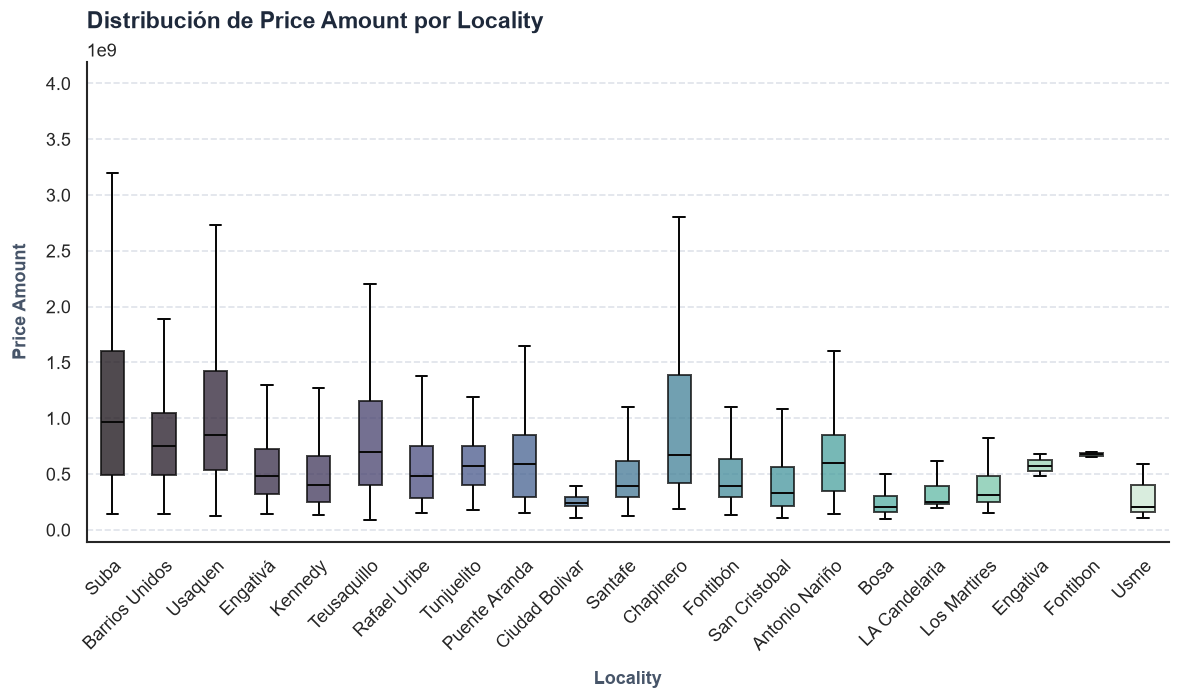

In [6]:
plot_segmented_boxplot(
    df, "price_amount", "locality", show_points=False, x_rotation=45
)

Las localidades con la bivienda mas barata son bosa y ciudad bolivar, mientras que Suba y Usaquen en general tienen bivienda mas costosa, algo de esperar considerando la coyuntura social de cada localidad

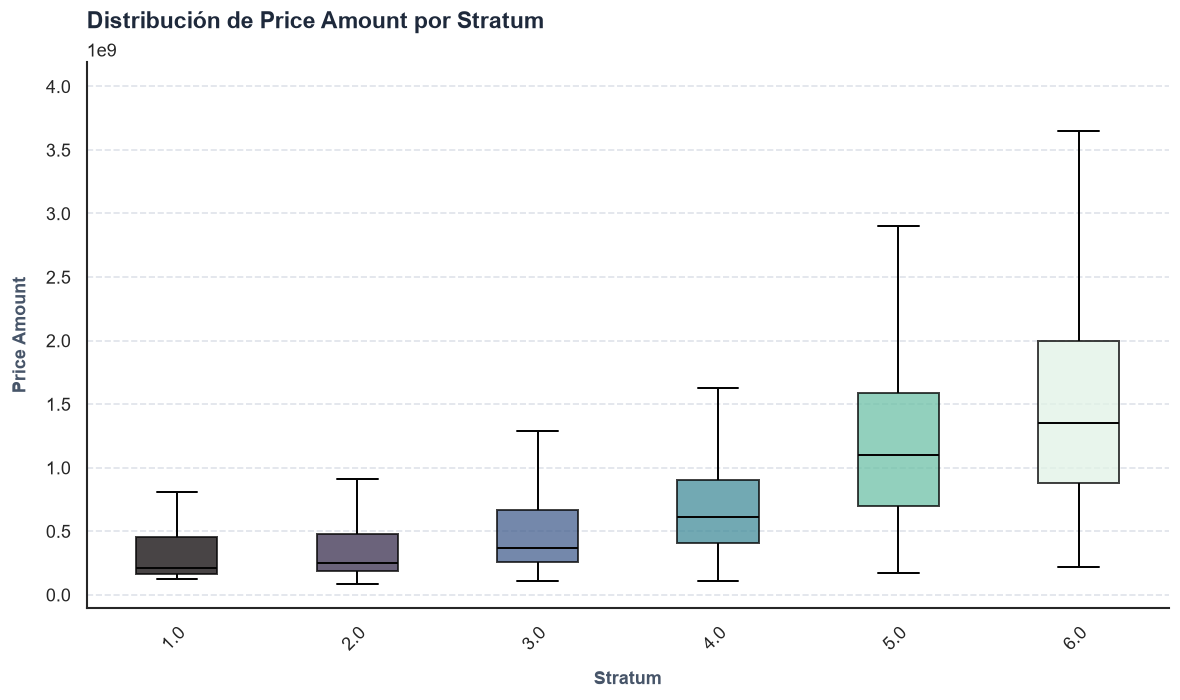

In [7]:
plot_segmented_boxplot(
    df, "price_amount", "stratum", show_points=False, x_rotation=45
)

Conforme sube el estrato tambien lo hacen los precios, este es el primer respaldo a la hipotesis 1.

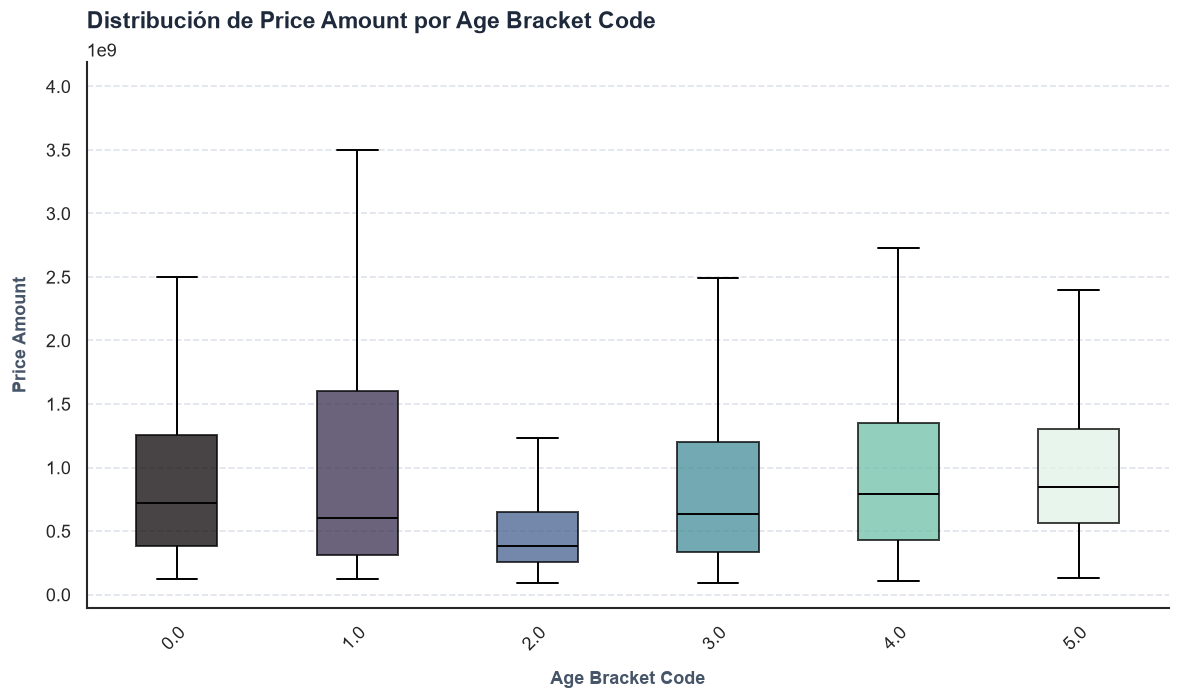

In [8]:
plot_segmented_boxplot(
    df, "price_amount", "age_bracket_code", show_points=False, x_rotation=45
)

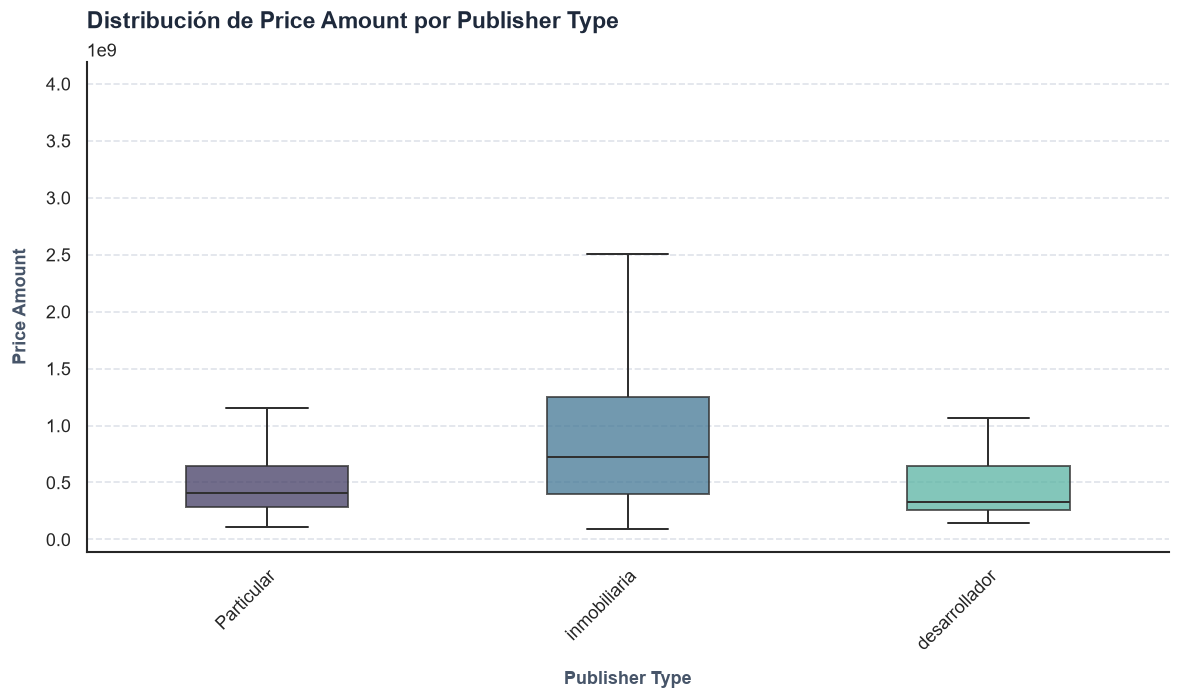

In [ ]:
plot_segmented_boxplot(
    df, "price_amount", "publisher_type", show_points=False, x_rotation=45
)

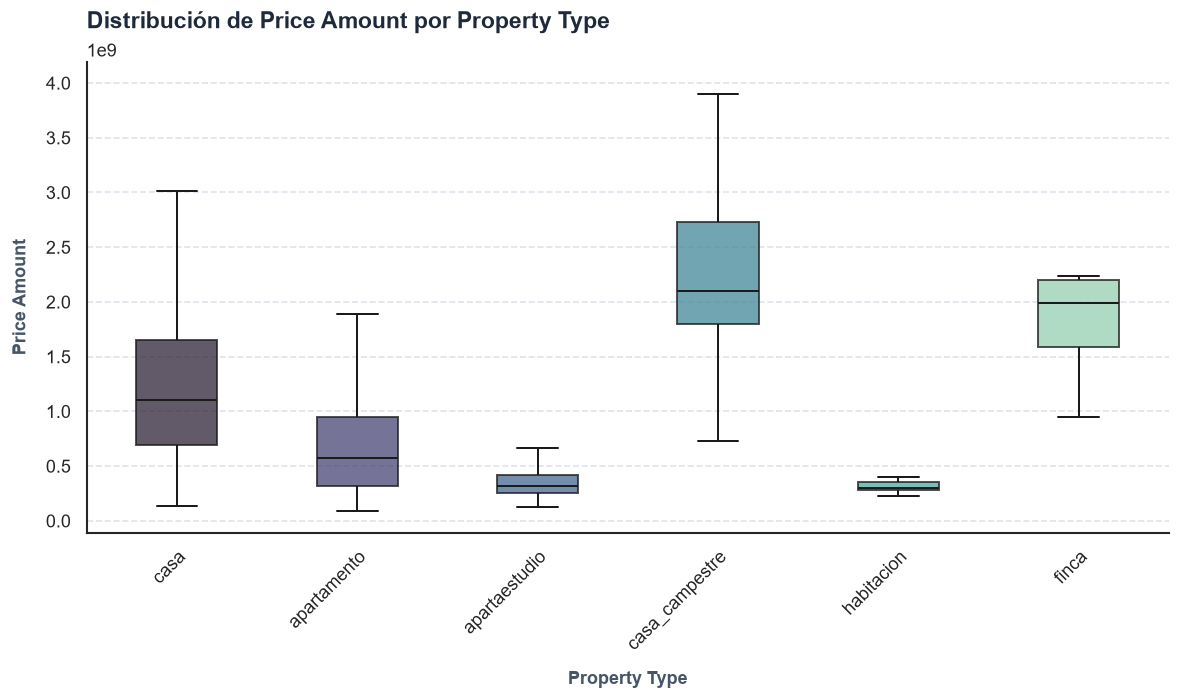

In [14]:
plot_segmented_boxplot(
    df, "price_amount", "property_type", show_points=False, x_rotation=45
)

## Scatter plots

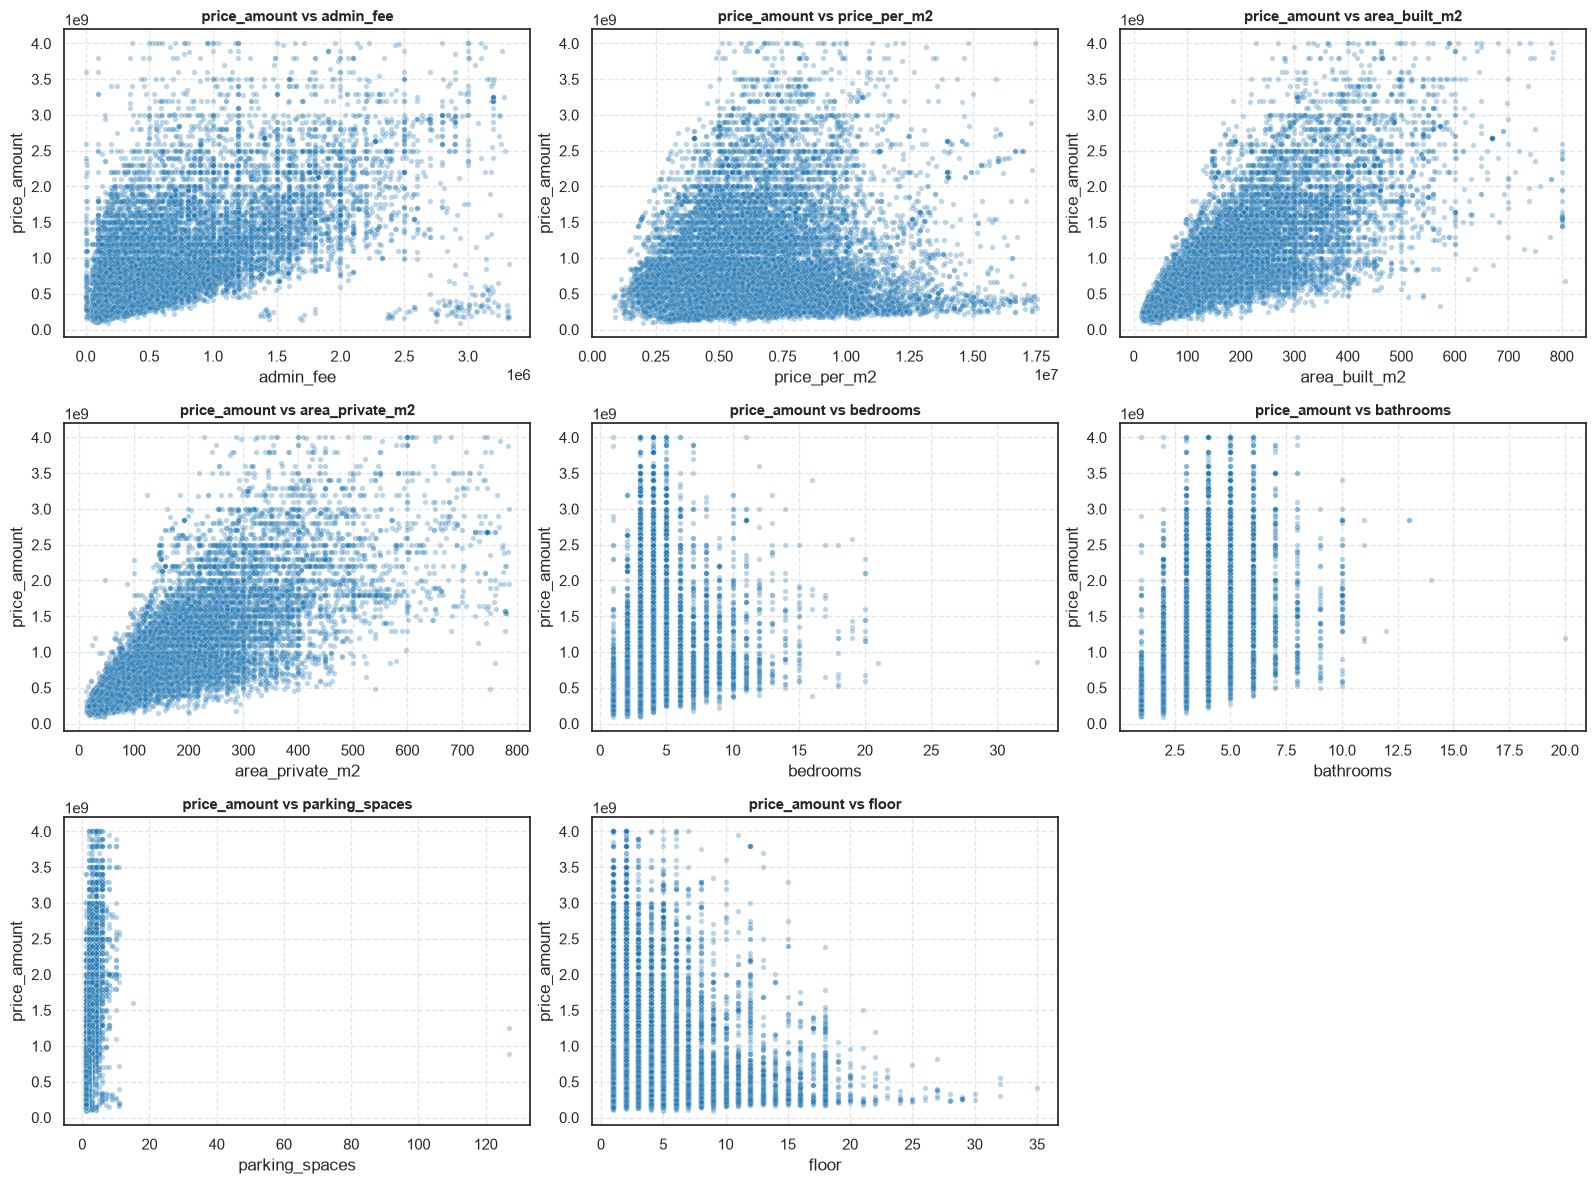

In [10]:
target = "price_amount"
predictors = [
    "admin_fee",
    "price_per_m2",
    "area_built_m2",
    "area_private_m2",
    "bedrooms",
    "bathrooms",
    "parking_spaces",
    "floor",
]

n_cols = 3
n_rows = math.ceil(len(predictors) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()


for i, col in enumerate(predictors):
    sns.scatterplot(
        data=df,
        x=col,
        y=target,
        ax=axes[i],
        alpha=0.3,
        s=15,
        color="#1f77b4",
    )

    axes[i].set_title(f"{target} vs {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)
    axes[i].grid(True, linestyle="--", alpha=0.5)


for i in range(len(predictors), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## Hypothesis test

In [11]:
df.columns

Index(['property_type', 'price_amount', 'admin_fee', 'price_per_m2',
       'area_built_m2', 'area_private_m2', 'bedrooms', 'bathrooms',
       'parking_spaces', 'stratum', 'floor', 'age_bracket_code',
       'age_bracket_label', 'construction_state', 'city', 'locality',
       'neighborhood', 'latitude', 'longitude', 'amenities', 'agency_name',
       'publisher_type', 'pub_month', 'mod_month', 'log_price_amount'],
      dtype='str')

In [12]:
cat_vars = ["property_type", "stratum", "age_bracket_code", "publisher_type"]

In [13]:
hub_pruebas_num_cat(df, "price_amount", cat_vars)

,var_numerica,var_categorica,n_grupos,prueba,estadistico,p_valor,normalidad,homocedasticidad,decision,conclusion,post_hoc
0,price_amount,property_type,6,Kruskal-Wallis (H),4203.5655,0.0,no,no,Se rechaza H0,Dependencia: la numérica difiere entre categorías,apartaestudio vs apartamento (p=0.0000); apart...
1,price_amount,stratum,6,Kruskal-Wallis (H),8257.5870,0.0,no,no,Se rechaza H0,Dependencia: la numérica difiere entre categorías,1.0 vs 3.0 (p=0.0033); 1.0 vs 4.0 (p=0.0000); ...
2,price_amount,age_bracket_code,6,Kruskal-Wallis (H),1882.6890,0.0,no,no,Se rechaza H0,Dependencia: la numérica difiere entre categorías,0.0 vs 2.0 (p=0.0000); 0.0 vs 3.0 (p=0.0080); ...
3,price_amount,publisher_type,3,Kruskal-Wallis (H),400.4959,0.0,no,no,Se rechaza H0,Dependencia: la numérica difiere entre categorías,Particular vs inmobiliaria (p=0.0000); desarro...


## Heat map

D:\Temp\ipykernel_8436\3872005954.py:1: UserWarning: corr_heatmap excluded 2 numeric-but-low-cardinality column(s) (stratum, age_bracket_code): a correlation over a small integer code is usually misleading. Pass include_low_cardinality=True to keep them.
  plotter.corr_heatmap(


<Axes: >

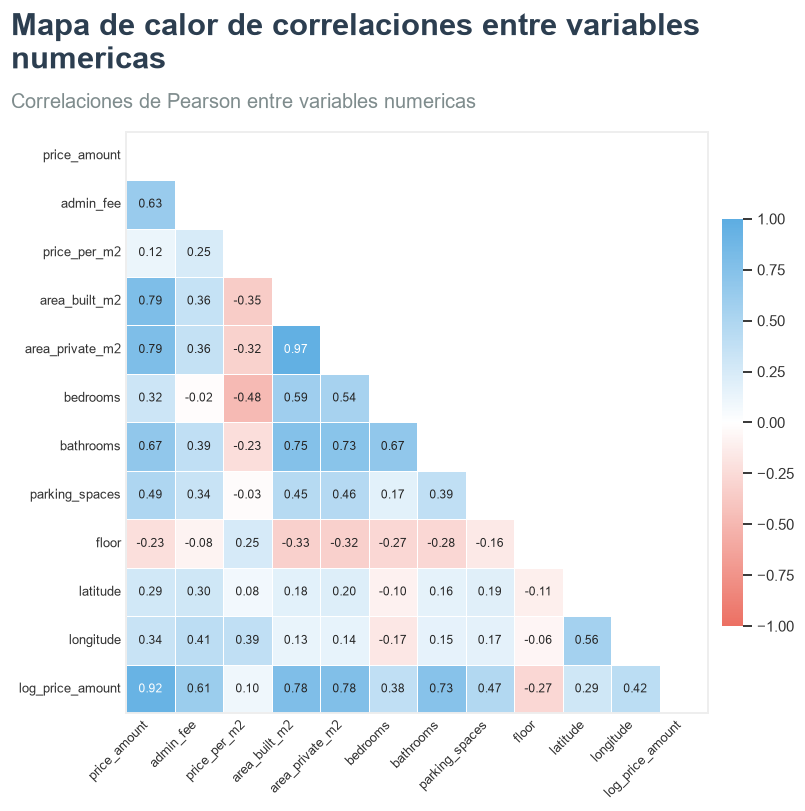

In [20]:
plotter.corr_heatmap(
    title="Mapa de calor de correlaciones entre variables numericas",
    subtitle="Correlaciones de Pearson entre variables numericas",
    annot=True,
    method="pearson",
)

despues de la limpieza se lograron observar correlaciones lineales, se refuta la hipotesis hecha en clase.

la correlacion es especialmente alta entre el precio y el area construida o privada, aunque estas 2 tambien tienen una alta relacion, se entrara a evaluar esto con VIF en una fase posterior

D:\Temp\ipykernel_8436\4115540453.py:1: UserWarning: corr_heatmap excluded 2 numeric-but-low-cardinality column(s) (stratum, age_bracket_code): a correlation over a small integer code is usually misleading. Pass include_low_cardinality=True to keep them.
  plotter.corr_heatmap(


<Axes: >

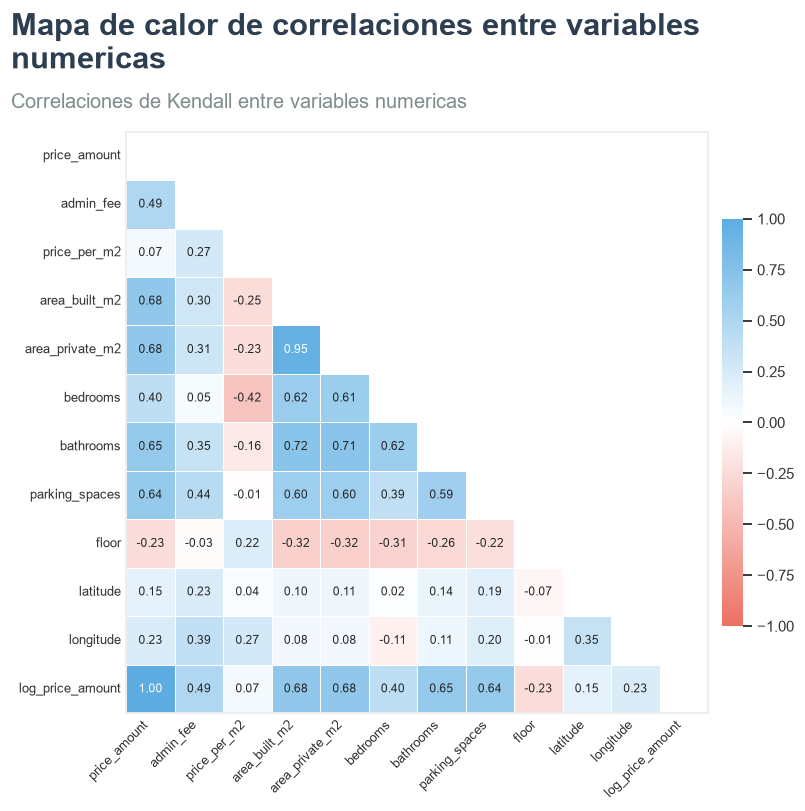

In [21]:
plotter.corr_heatmap(
    title="Mapa de calor de correlaciones entre variables numericas",
    subtitle="Correlaciones de Kendall entre variables numericas",
    method="kendall",
    annot=True,
)